<a href="https://colab.research.google.com/github/Thienluong9999/IoT_ph-ng_kh-m_th-_y/blob/main/MLTrain_Notebook/Notebook/ML/MLEsp32.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


--- DEBUG TÍN HIỆU TIỀN XỬ LÝ ---
Max abs pct_change sau khi clip: 400.0
---------------------------------


--- THÔNG SỐ RANH GIỚI K-MEANS & HYSTERESIS (Buffer Cố Định: ±10.0 pp) ---
L0/L1 -> Tâm b01: -15.15% | ON (>): -5.15% | OFF (<): -25.15%
L1/L2 -> Tâm b12: 39.78% | ON (>): 49.78% | OFF (<): 29.78%
L2/L3 -> Tâm b23: 213.80% | ON (>): 223.80% | OFF (<): 203.80%
-------------------------------------------------------------------------


========== 1. ĐÁNH GIÁ BỘ LỌC DEBOUNCE ==========
Số lần trạng thái nhảy mức (Chưa lọc) : 653 lần
Số lần trạng thái nhảy mức (Đã lọc)   : 205 lần

========== 2. ĐÁNH GIÁ HIỆU NĂNG MOLR (Dự báo t+6 Bước) ==========
RMSE Baseline (Mô hình lười)          : 7.6384
RMSE MOLR (Khi đã hội tụ)             : 7.1152
-> MOLR cải thiện được                : 6.85% so với Baseline

========== 3. SO SÁNH VỚI MÔ HÌNH TUYẾN TÍNH AR(1) ==========
RMSE AR(1)         : 7.4380 (Cải thiện 2.62%)
RMSE MOLR          : 7.1152 (Cải thiện 6.85%)


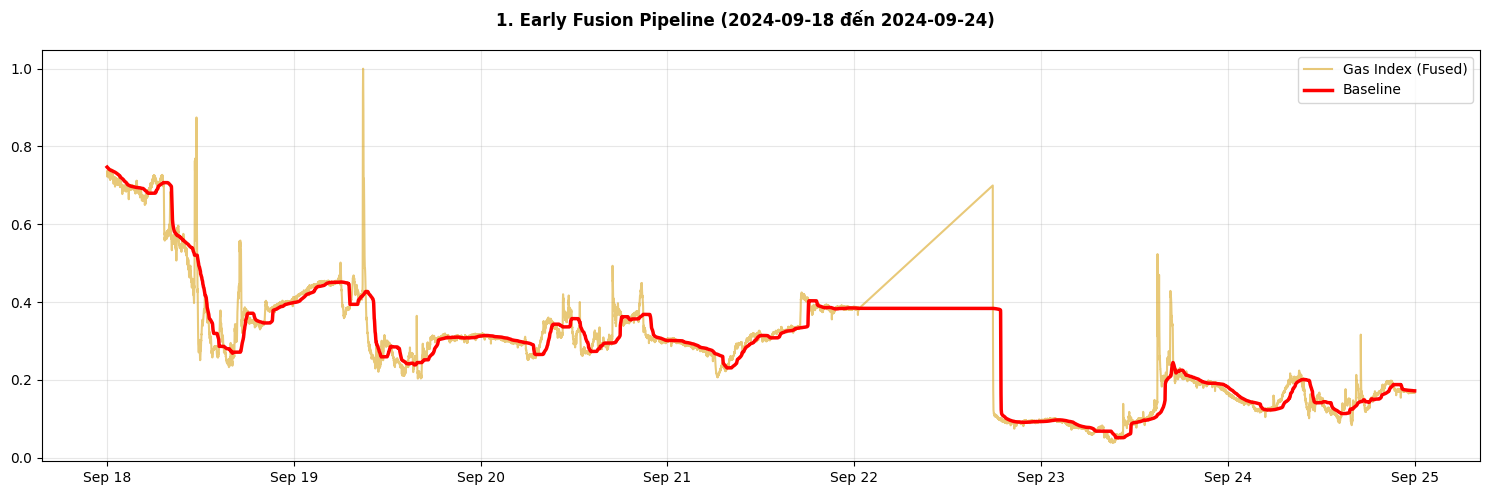


Đang chạy K-Means và Ablation Test...


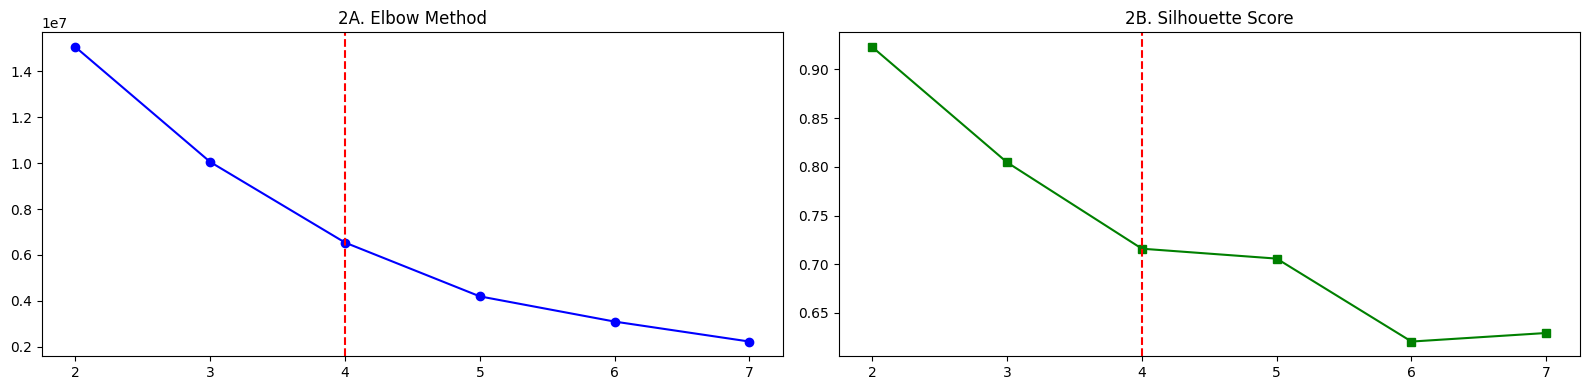

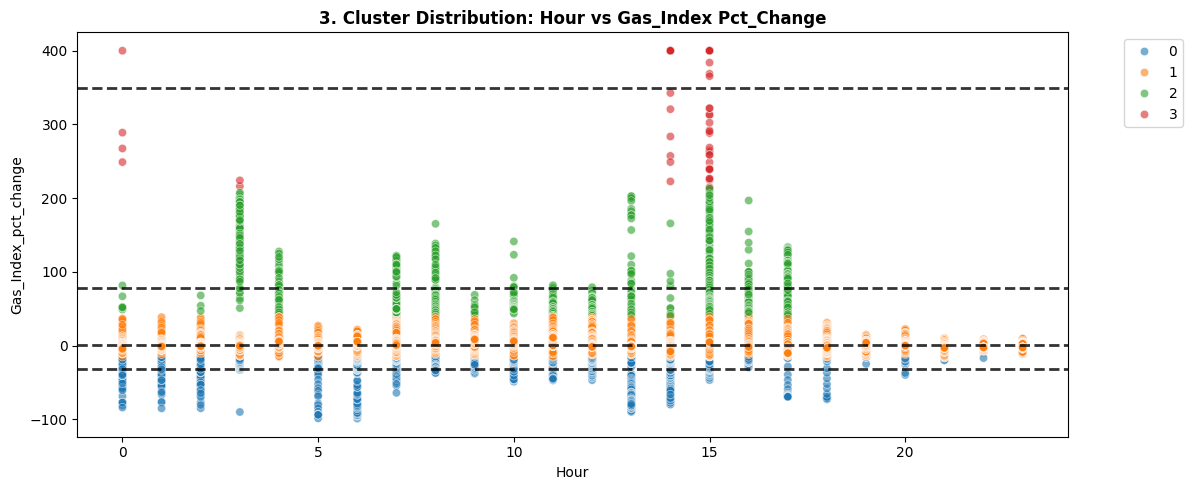

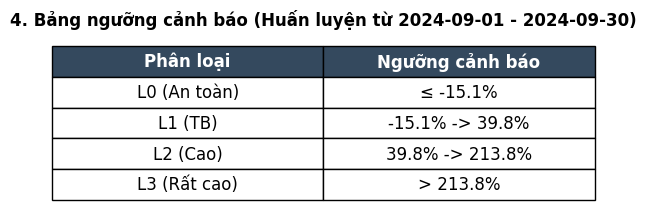


========== 5. PHÂN TÍCH PACF CHI TIẾT (1 -> 20 LAGS) ==========
 Lag (Độ trễ)  Hệ số PACF  Cận dưới 95%  Cận trên 95%            Khuyến nghị
            1      0.9814        0.9726        0.9902 ⭐⭐ Cực mạnh (Nên chọn)
            2      0.0597        0.0509        0.0685             ⭐ Khá mạnh
            3      0.1087        0.0999        0.1175             ⭐ Khá mạnh
            4     -0.0124       -0.0212       -0.0036   Loại (Tương quan âm)
            5      0.0272        0.0184        0.0360       Có ảnh hưởng nhẹ
            6      0.0077       -0.0011        0.0165         Nhiễu (Bỏ qua)
            7      0.0062       -0.0026        0.0150         Nhiễu (Bỏ qua)
            8     -0.0213       -0.0301       -0.0125   Loại (Tương quan âm)
            9      0.0261        0.0173        0.0349       Có ảnh hưởng nhẹ
           10     -0.0048       -0.0136        0.0040         Nhiễu (Bỏ qua)
           11      0.0034       -0.0054        0.0122         Nhiễu (Bỏ qua)
           

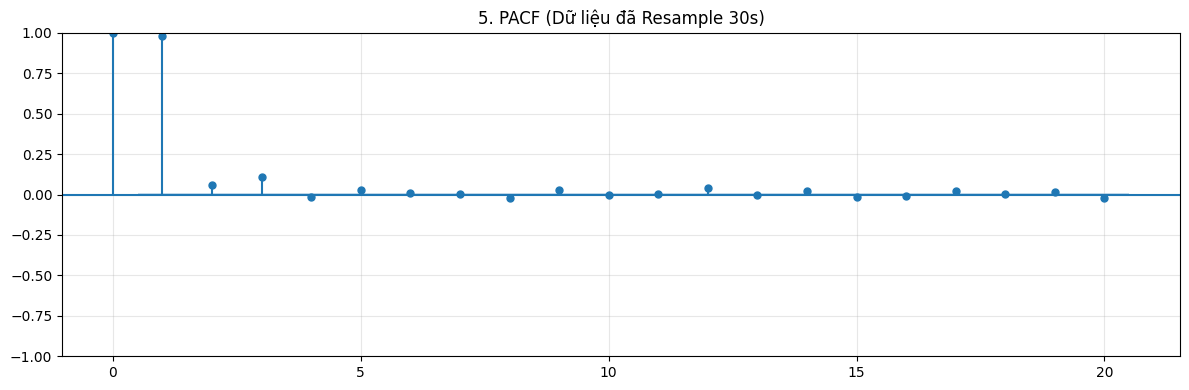


========== KẾT QUẢ ABLATION TEST (DATAFRAME) ==========


,Kịch bản,Lags,Features,RMSE Base,RMSE MOLR,Cải (%)
0,"Chỉ Gas Index (Lags [1, 2, 3])","[1, 2, 3]",6,7.6384,7.2565,5.00
1,"Lịch sử dài [1,12,36]","[1, 12, 36]",6,7.6410,7.2002,5.77
2,PACF Đỉnh Nhất,"[1, 2]",5,7.6384,7.2970,4.47
3,Mật độ cao,"[1, 2, 3, 4, 5]",8,7.6385,7.3755,3.44
4,"PACF Đề xuất [1,2,4]","[1, 2, 4]",6,7.6385,7.2154,5.54
5,"PACF Đầy đủ [1,2,3,4]","[1, 2, 3, 4]",7,7.6385,7.2492,5.10
6,"+ Temp & Humid (Lags [1, 2, 3])","[1, 2, 3]",8,7.6384,7.1152,6.85


------------------------------------------------------



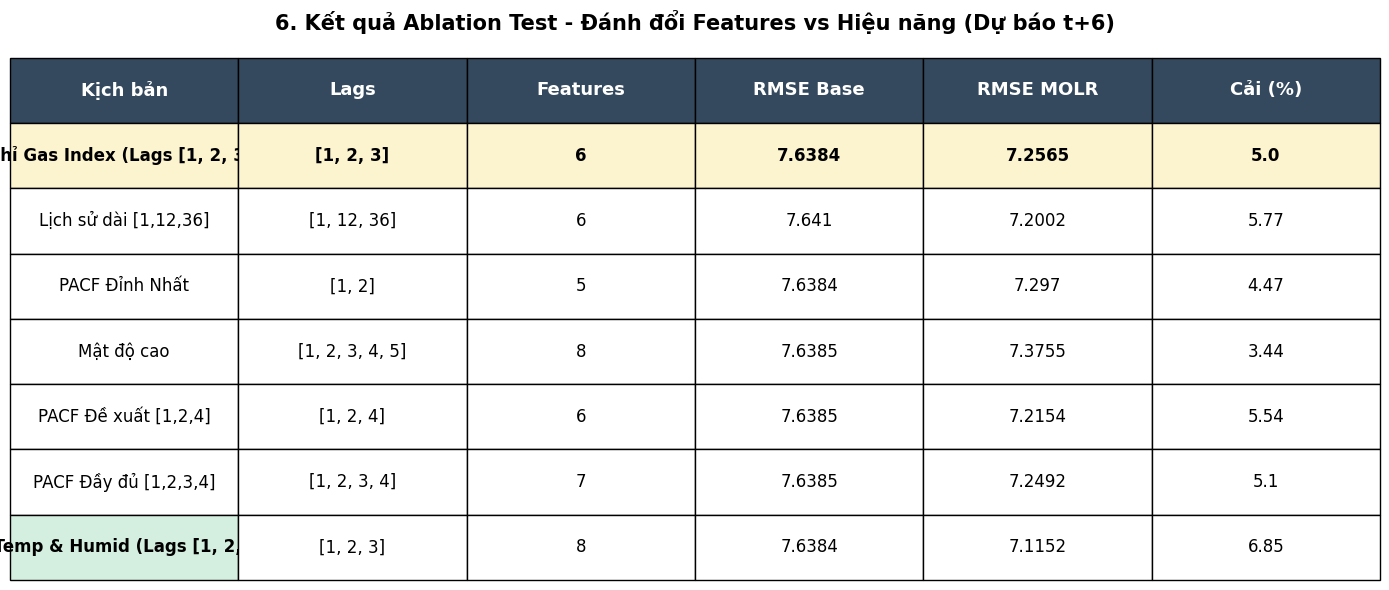

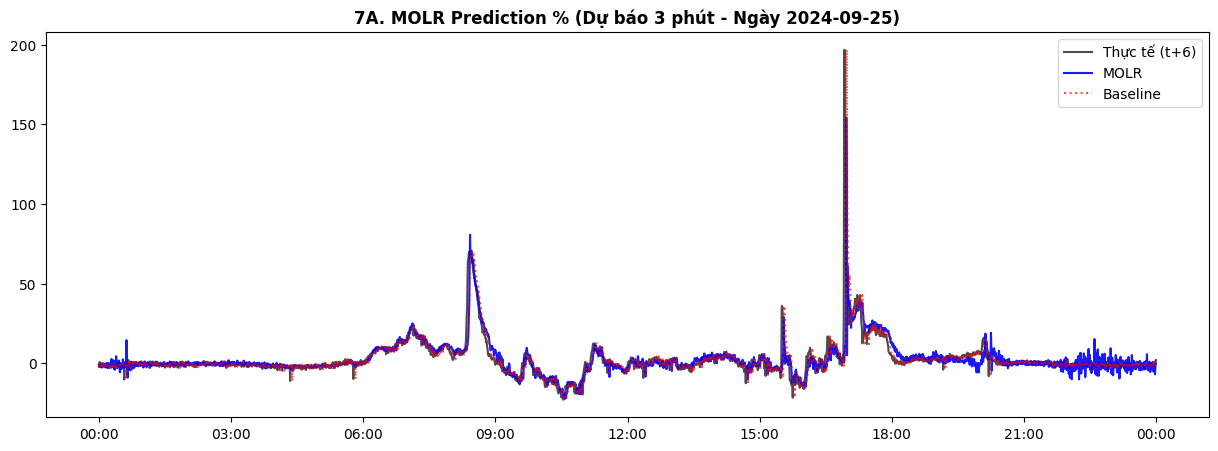

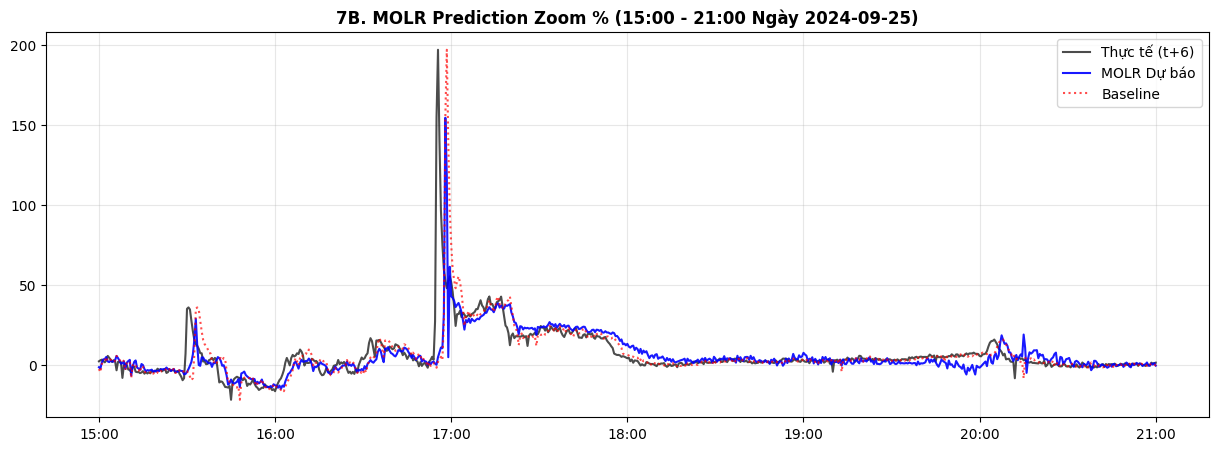

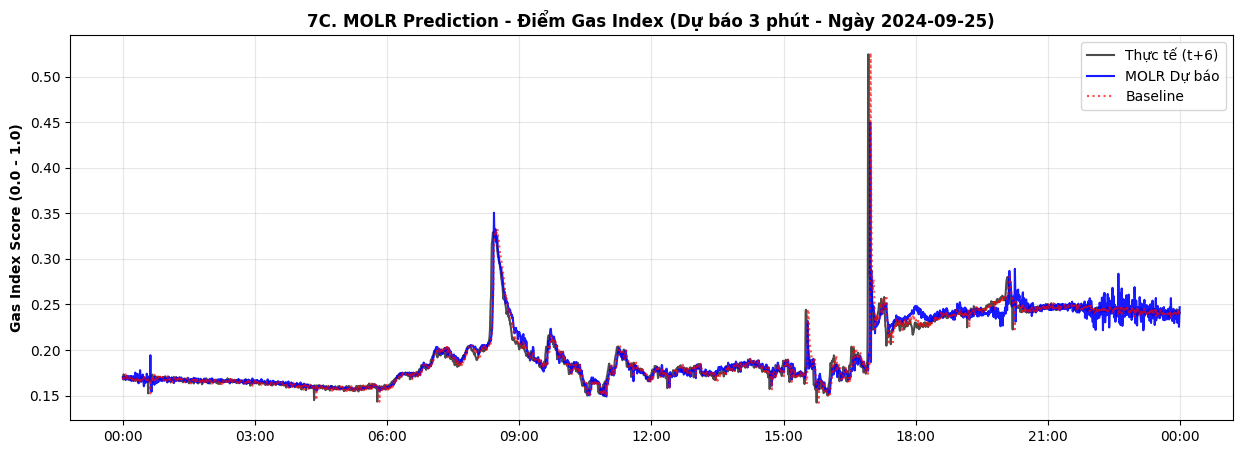

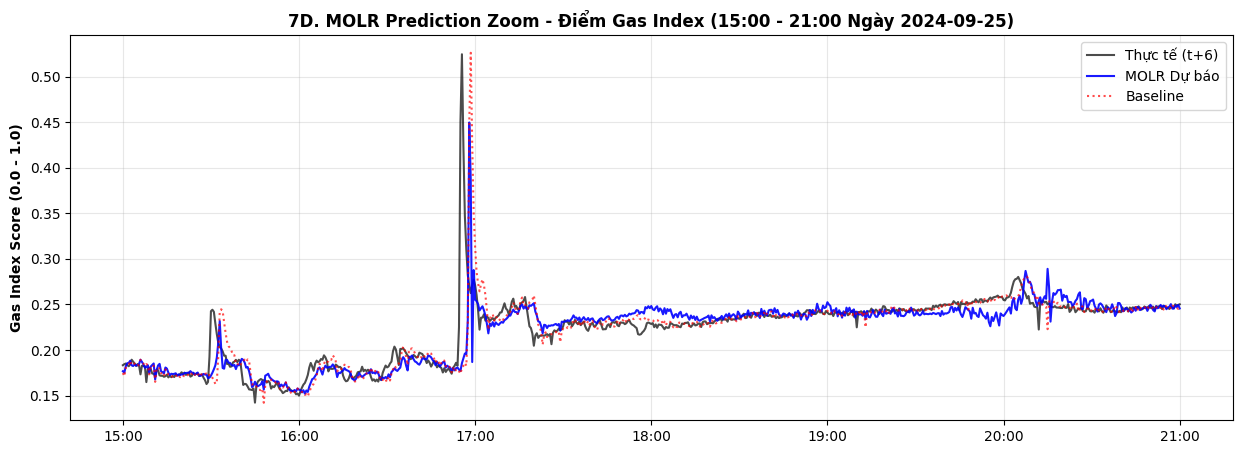

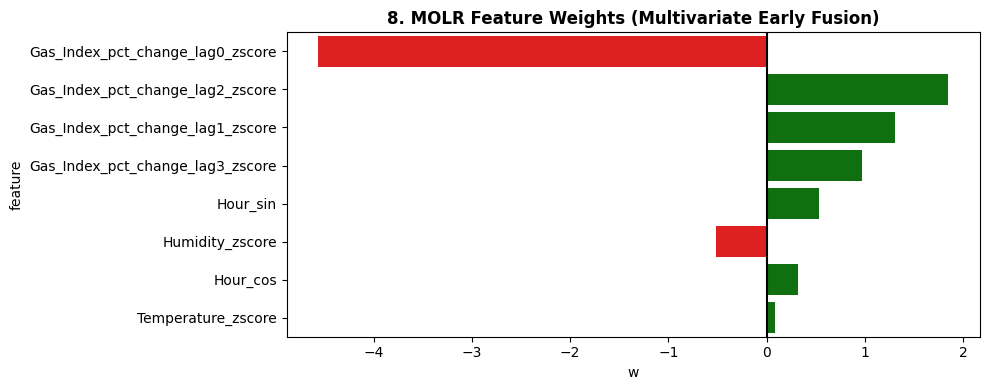

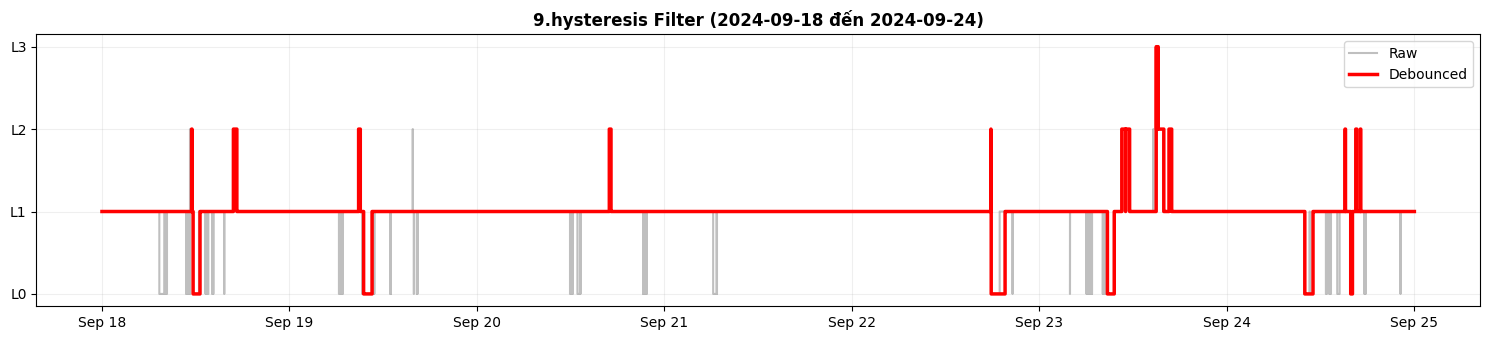


========== ĐANG VẼ MA TRẬN TƯƠNG QUAN ==========



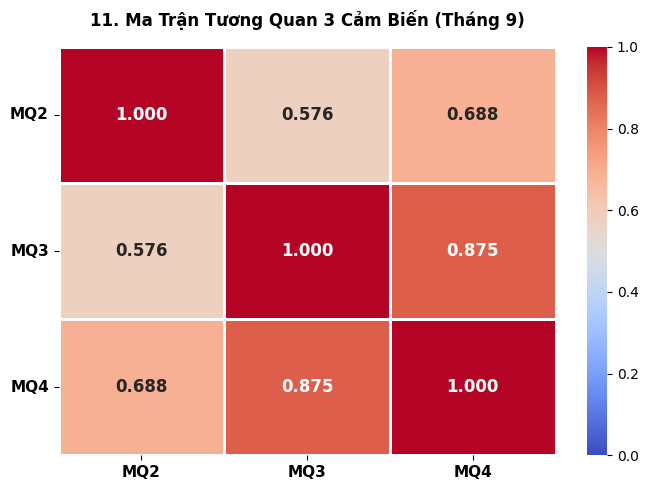

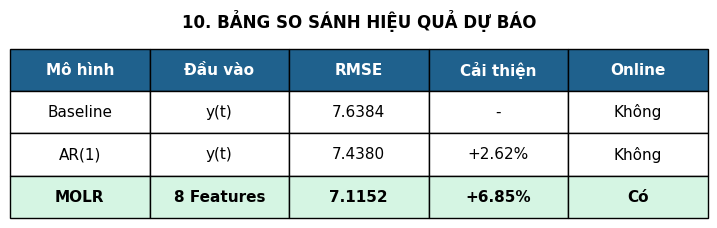


========== KẾT QUẢ TRỌNG SỐ MOLR (W & BIAS) ==========

Hệ số lệch (bias b) = -0.215499

// Copy đoạn này dán thẳng vào code C/C++ trên ESP32:
const float b = -0.215499f;
const float w[8] = {
     -4.561816f, // w[ 0]: Gas_Index_pct_change_lag0_zscore
      1.308475f, // w[ 1]: Gas_Index_pct_change_lag1_zscore
      1.850149f, // w[ 2]: Gas_Index_pct_change_lag2_zscore
      0.973745f, // w[ 3]: Gas_Index_pct_change_lag3_zscore
      0.083702f, // w[ 4]: Temperature_zscore
     -0.518830f, // w[ 5]: Humidity_zscore
      0.531231f, // w[ 6]: Hour_sin
      0.320802f // w[ 7]: Hour_cos
};


In [71]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import warnings
import re
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from statsmodels.graphics.tsaplots import plot_pacf
from sklearn.linear_model import LinearRegression
from statsmodels.tsa.stattools import pacf

warnings.filterwarnings('ignore')

# ==============================================================================
# [ KHU VỰC TINH CHỈNH THÔNG SỐ (ĐIỀU KHIỂN TẠI ĐÂY) ]
# ==============================================================================
# T = NHỊP ĐỒNG HỒ GỐC (Thời gian gộp 1 mẫu dữ liệu)
CONFIG_RESAMPLE_WINDOW = "30s"
# Ý nghĩa: Nén mỗi 30 giây dữ liệu cảm biến thành 1 mẫu duy nhất.

# 1. THÔNG SỐ THỜI GIAN & THUẬT TOÁN (Nhóm nhân với T)
CONFIG_TARGET_STEP = 6
# Ý nghĩa: Khung thời gian dự báo tương lai.
# Cách tính: 6 nhịp x 30s = 180s = 3 phút.
# -> Mô hình sẽ cố gắng dự báo nồng độ khí gas ở thời điểm 3 phút tiếp theo.

#CONFIG_LAGS = [17,18,42,57]
CONFIG_LAGS = [1,2,3]
# Ý nghĩa: Trích xuất các sự kiện trong quá khứ để làm cơ sở dự báo tương lai.
# Cách tính:
#   - Lag 1: 1 x 30s = 30 giây trước.
#   - Lag 2: 2 x 30s = 1 phút trước.
#   - Lag 14: 14 x 30s = 7 phút trước.
# -> Thuật toán sẽ dùng trạng thái mùi hôi của 30s, 1p và 7p trước để đoán 3p tới.

CONFIG_LEARNING_RATE = 0.005
# Ý nghĩa: Bước nhảy của thuật toán Cập nhật trực tuyến (SGD).
# Tác dụng: 0.005 là mức khá "gắt". Giúp mô hình bắt kịp ngay lập tức khi phát hiện đỉnh mùi hôi (chống hiện tượng dự báo bị trễ nhịp).

CONFIG_L2_PENALTY = 0.02
# Ý nghĩa: Dây cương hãm phanh (Thẻ phạt L2).
# Tác dụng: Giới hạn độ lớn của các trọng số W. Số 0.01 giữ cho hệ thống không bị "học vẹt" vào các nhiễu rác điện áp, nhưng vẫn đủ nhỏ để mô hình không quá lười biếng.

# 2. THÔNG SỐ TIỀN XỬ LÝ & KHỬ NHIỄU (Nhóm chia cho T)
CONFIG_MEDIAN_WINDOW = 1
# Ý nghĩa: Cửa sổ lọc nhiễu trung vị (Rolling Median / Hampel).
# Cách tính: 6 nhịp x 30s = 180s = 3 phút.
# -> Lọc bỏ hoàn toàn các gai điện áp ảo diễn ra chớp nhoáng (chỉ lấy giá trị trung vị trong khoảng 3 phút liên tục).

CONFIG_MA_WINDOW = 240
# Ý nghĩa: Cửa sổ tạo Đường nền (Baseline) thay đổi chậm.
# Cách tính: 180 nhịp x 30s = 5400s = 90 phút (1.5 tiếng).
# -> Hệ thống sẽ lấy trung bình 1.5 tiếng gần nhất làm mốc chuẩn (điểm số 0) để đánh giá không khí hiện tại là "sạch" hay "bẩn", bất chấp thay đổi thời tiết.

CONFIG_DEBOUNCE_CONFIRM =  3
# Ý nghĩa: Độ trễ an toàn trước khi kích hoạt còi báo động.
# Cách tính: 3 nhịp x 30s = 90s = 1.5 phút.
# -> Khi thuật toán phát hiện nguy hiểm, nó không hú còi ngay mà sẽ "nín thở" chờ thêm 1.5 phút để xác nhận chắc chắn mùi hôi chưa biến mất, chống còi kêu chập chờn.

CONFIG_PACF_MAX_LAGS = 20
CONFIG_PACF_PLOT_LAGS = 20

CONFIG_PLOT_7D_START = "2024-09-18"
CONFIG_PLOT_7D_END = "2024-09-24"
CONFIG_PLOT_TEST_DAY = "2024-09-25"
CONFIG_KMEANS_START = "2024-09-01"
CONFIG_KMEANS_END = "2024-09-30"

num_val = int(re.search(r'\d+', CONFIG_RESAMPLE_WINDOW).group())
if 's' in CONFIG_RESAMPLE_WINDOW.lower():
    step_minutes = num_val / 60.0
elif 'min' in CONFIG_RESAMPLE_WINDOW.lower() or 't' in CONFIG_RESAMPLE_WINDOW.lower():
    step_minutes = num_val
else:
    step_minutes = 1.0

PREDICT_MINUTES = int(CONFIG_TARGET_STEP * step_minutes) if (CONFIG_TARGET_STEP * step_minutes).is_integer() else round(CONFIG_TARGET_STEP * step_minutes, 1)

# ==============================================================================
# 0. ĐỌC DỮ LIỆU & LÀM SẠCH
# ==============================================================================
file_path = "TD3_ESP32_SMELL.xlsx"
df = pd.read_excel(file_path, skiprows=1, usecols="A:H")
df.columns = ["Date", "Time", "Status", "Temperature", "Humidity", "MQ2", "MQ3", "MQ4"]

numeric_cols = ["Temperature", "Humidity", "MQ2", "MQ3", "MQ4"]
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

temp_datetime_str = df["Date"].astype(str).str.strip() + " " + df["Time"].astype(str).str.strip()
parsed_dates = pd.Series(pd.NaT, index=df.index)

mask_dash = df["Date"].astype(str).str.contains("-")
if mask_dash.sum() > 0:
    parsed_dates[mask_dash] = pd.to_datetime(temp_datetime_str[mask_dash], format="%Y-%d-%m %H:%M:%S", errors="coerce")

mask_slash = df["Date"].astype(str).str.contains("/")
if mask_slash.sum() > 0:
    parsed_dates[mask_slash] = pd.to_datetime(temp_datetime_str[mask_slash], format="%d/%m/%Y %H:%M:%S", errors="coerce")

df["Timestamp"] = parsed_dates
df = df.dropna(subset=["Timestamp"])
df.drop(columns=["Date", "Time"], inplace=True)
df = df.sort_values("Timestamp").reset_index(drop=True)

min_time = df["Timestamp"].min()
df = df[df["Timestamp"] >= (min_time + pd.Timedelta(days=5))].reset_index(drop=True)

df = df.set_index("Timestamp").resample(CONFIG_RESAMPLE_WINDOW).mean(numeric_only=True).dropna().reset_index()
df["Hour"] = df["Timestamp"].dt.hour

# ==============================================================================
# PHASE 1: SENSOR FUSION & PREPROCESSING (HAMPEL FILTER + ROLLING MEDIAN)
# ==============================================================================
EPS = 0.01
HAMPEL_K = 3

for sensor in ["MQ2", "MQ3", "MQ4"]:
    rolling_median = df[sensor].rolling(window=CONFIG_MEDIAN_WINDOW, min_periods=1).median()
    rolling_mad = (df[sensor] - rolling_median).abs().rolling(window=CONFIG_MEDIAN_WINDOW, min_periods=1).median()
    threshold = HAMPEL_K * 1.4826 * rolling_mad
    outlier_mask = (df[sensor] - rolling_median).abs() > threshold
    df[f"{sensor}_med"] = np.where(outlier_mask, rolling_median, df[sensor])

for sensor in ["MQ2", "MQ3", "MQ4"]:
    s_min_exp = df[f"{sensor}_med"].expanding().min()
    s_max_exp = df[f"{sensor}_med"].expanding().max()
    df[f"{sensor}_norm"] = (df[f"{sensor}_med"] - s_min_exp) / (s_max_exp - s_min_exp + EPS)

df["Gas_Index"] = (df["MQ2_norm"] + df["MQ3_norm"] + df["MQ4_norm"]) / 3.0

df["Gas_Index_baseline"] = df["Gas_Index"].rolling(window=CONFIG_MA_WINDOW, min_periods=1).median()
df["Gas_Index_detrend"] = df["Gas_Index"] - df["Gas_Index_baseline"]
df["Gas_Index_pct_change"] = (df["Gas_Index_detrend"] / (df["Gas_Index_baseline"] + EPS)) * 100

# KÉP CỔ OUTLIER CỰC ĐOAN (CHẶN ĐỨNG > 400%)
df["Gas_Index_pct_change"] = df["Gas_Index_pct_change"].clip(lower=-100.0, upper=400.0)

print("\n--- DEBUG TÍN HIỆU TIỀN XỬ LÝ ---")
print("Max abs pct_change sau khi clip:", df["Gas_Index_pct_change"].abs().max())
print("---------------------------------\n")

# ==============================================================================
# PHASE 2: PHÂN CỤM K-MEANS
# ==============================================================================
mask_sep = (df["Timestamp"] >= f"{CONFIG_KMEANS_START} 00:00:00") & (df["Timestamp"] <= f"{CONFIG_KMEANS_END} 23:59:59")
df_1_month = df[mask_sep]

X_train_kmeans = df_1_month[["Gas_Index_pct_change"]].dropna().values
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
kmeans.fit(X_train_kmeans)

raw_labels = kmeans.predict(df[["Gas_Index_pct_change"]].fillna(0).values)

centers = kmeans.cluster_centers_.flatten()
sorted_idx = np.argsort(centers)
label_map = {old_cluster: new_level for new_level, old_cluster in enumerate(sorted_idx)}
df["pollution_level"] = [label_map[label] for label in raw_labels]

sorted_centers = np.sort(centers)
b01 = (sorted_centers[0] + sorted_centers[1]) / 2
b12 = (sorted_centers[1] + sorted_centers[2]) / 2
b23 = (sorted_centers[2] + sorted_centers[3]) / 2

# ==============================================================================
# PHASE 3 & 4: FEATURE ENGINEERING & ONLINE MOLR
# ==============================================================================
df[f"target_t{CONFIG_TARGET_STEP}"] = df["Gas_Index_pct_change"].shift(-CONFIG_TARGET_STEP)

lag_cols = []
df["Gas_Index_pct_change_lag0"] = df["Gas_Index_pct_change"]
lag_cols.append("Gas_Index_pct_change_lag0")

for lag in CONFIG_LAGS:
    col_name = f"Gas_Index_pct_change_lag{lag}"
    df[col_name] = df["Gas_Index_pct_change"].shift(lag)
    lag_cols.append(col_name)

df["Hour_sin"] = np.sin(2 * np.pi * df["Hour"] / 24)
df["Hour_cos"] = np.cos(2 * np.pi * df["Hour"] / 24)

extra_features = ["Temperature", "Humidity"]
all_features_to_zscore = lag_cols + extra_features

for col in all_features_to_zscore:
    roll = df[col].rolling(window=CONFIG_MA_WINDOW, min_periods=1)
    std_floor = roll.std().clip(lower=0.01)
    df[f"{col}_zscore"] = (df[col] - roll.mean()) / std_floor

df_molr = df.dropna().copy()
feature_cols = [f"{col}_zscore" for col in all_features_to_zscore] + ["Hour_sin", "Hour_cos"]

X_online = df_molr[feature_cols].values
y_current = df_molr["Gas_Index_pct_change"].values
y_true_target = df_molr[f"target_t{CONFIG_TARGET_STEP}"].values
delta_y = y_true_target - y_current

w = np.zeros(X_online.shape[1])
b = 0.0
delta_pred_molr = np.zeros(len(delta_y))

for i in range(len(X_online)):
    d_hat = np.dot(w, X_online[i]) + b
    delta_pred_molr[i] = d_hat
    err = d_hat - delta_y[i]
    w -= CONFIG_LEARNING_RATE * (err * X_online[i] + CONFIG_L2_PENALTY * w)
    b -= CONFIG_LEARNING_RATE * err

y_pred_molr = y_current + delta_pred_molr
split_idx = int(len(y_true_target) * 0.5)
rmse_baseline_stable = np.sqrt(np.mean((y_true_target[split_idx:] - y_current[split_idx:])**2))
rmse_molr_stable = np.sqrt(np.mean((y_true_target[split_idx:] - y_pred_molr[split_idx:])**2))
improvement_stable = ((rmse_baseline_stable - rmse_molr_stable) / rmse_baseline_stable) * 100

# ==============================================================================
# PHASE 5: BỘ LỌC HYSTERESIS ĐA NGƯỠNG (BUFFER TUYỆT ĐỐI CỐ ĐỊNH)
# ==============================================================================
BUFFER_PP = 10.0  # Biên độ đệm cố định: ±10 điểm phần trăm cho mọi ranh giới

def apply_absolute_multilevel_hysteresis(pct_change_series, centers, buffer_pp):
    b01, b12, b23 = centers[0], centers[1], centers[2]

    # Áp dụng buffer tuyệt đối (Cộng/trừ hằng số, độc lập với độ lớn của tâm cụm)
    on_01 = b01 + buffer_pp
    off_01 = b01 - buffer_pp

    on_12 = b12 + buffer_pp
    off_12 = b12 - buffer_pp

    on_23 = b23 + buffer_pp
    off_23 = b23 - buffer_pp

    final_levels = []
    current_level = 0

    for val in pct_change_series:
        if current_level == 0:
            if val > on_01: current_level = 1
        elif current_level == 1:
            if val > on_12: current_level = 2
            elif val < off_01: current_level = 0
        elif current_level == 2:
            if val > on_23: current_level = 3
            elif val < off_12: current_level = 1
        elif current_level == 3:
            if val < off_23: current_level = 2

        final_levels.append(current_level)

    return final_levels

df["Final_Alarm_Level"] = apply_absolute_multilevel_hysteresis(
    df["Gas_Index_pct_change"],
    [b01, b12, b23],
    buffer_pp=BUFFER_PP
)

# --- DEBUG THÔNG SỐ HYSTERESIS TUYỆT ĐỐI ĐÃ ĐỒNG BỘ ---
print(f"\n--- THÔNG SỐ RANH GIỚI K-MEANS & HYSTERESIS (Buffer Cố Định: ±{BUFFER_PP} pp) ---")
print(f"L0/L1 -> Tâm b01: {b01:.2f}% | ON (>): {b01 + BUFFER_PP:.2f}% | OFF (<): {b01 - BUFFER_PP:.2f}%")
print(f"L1/L2 -> Tâm b12: {b12:.2f}% | ON (>): {b12 + BUFFER_PP:.2f}% | OFF (<): {b12 - BUFFER_PP:.2f}%")
print(f"L2/L3 -> Tâm b23: {b23:.2f}% | ON (>): {b23 + BUFFER_PP:.2f}% | OFF (<): {b23 - BUFFER_PP:.2f}%")
print("-------------------------------------------------------------------------\n")

# ==============================================================================
# PHẦN IN SỐ LIỆU ĐÁNH GIÁ (TERMINAL)
# ==============================================================================
print("\n========== 1. ĐÁNH GIÁ BỘ LỌC DEBOUNCE ==========")
raw_flips = (df["pollution_level"] != df["pollution_level"].shift()).sum()
final_flips = (df["Final_Alarm_Level"] != df["Final_Alarm_Level"].shift()).sum()
print(f"Số lần trạng thái nhảy mức (Chưa lọc) : {raw_flips} lần")
print(f"Số lần trạng thái nhảy mức (Đã lọc)   : {final_flips} lần")

print(f"\n========== 2. ĐÁNH GIÁ HIỆU NĂNG MOLR (Dự báo t+{CONFIG_TARGET_STEP} Bước) ==========")
print(f"RMSE Baseline (Mô hình lười)          : {rmse_baseline_stable:.4f}")
print(f"RMSE MOLR (Khi đã hội tụ)             : {rmse_molr_stable:.4f}")
if rmse_molr_stable < rmse_baseline_stable:
    print(f"-> MOLR cải thiện được                : {improvement_stable:.2f}% so với Baseline")
else:
    loss = ((rmse_molr_stable - rmse_baseline_stable) / rmse_baseline_stable) * 100
    print(f"-> MOLR kém hơn Baseline              : {loss:.2f}% (Cần tinh chỉnh lại Lags ở Bảng điều khiển)")

print("\n========== 3. SO SÁNH VỚI MÔ HÌNH TUYẾN TÍNH AR(1) ==========")
X_train_ar, y_train_ar = y_current[:split_idx].reshape(-1, 1), y_true_target[:split_idx]
ar1_model = LinearRegression().fit(X_train_ar, y_train_ar)
y_pred_ar1 = ar1_model.predict(y_current[split_idx:].reshape(-1, 1))
rmse_ar1 = np.sqrt(np.mean((y_true_target[split_idx:] - y_pred_ar1)**2))
imp_ar1 = ((rmse_baseline_stable - rmse_ar1) / rmse_baseline_stable) * 100

print(f"RMSE AR(1)         : {rmse_ar1:.4f} (Cải thiện {imp_ar1:.2f}%)")
print(f"RMSE MOLR          : {rmse_molr_stable:.4f} (Cải thiện {improvement_stable:.2f}%)")

# ==============================================================================
# 9 BIỂU ĐỒ & BẢNG VISUALIZATION (GIỮ NGUYÊN 100% ĐỦ CÁC BIỂU ĐỒ)
# ==============================================================================
mask_7d = (df["Timestamp"] >= f"{CONFIG_PLOT_7D_START} 00:00:00") & (df["Timestamp"] <= f"{CONFIG_PLOT_7D_END} 23:59:59")
df_plot_7d = df[mask_7d]

# 1. Pipeline
fig, ax = plt.subplots(figsize=(15, 5))
fig.suptitle(f'1. Early Fusion Pipeline ({CONFIG_PLOT_7D_START} đến {CONFIG_PLOT_7D_END})', weight='bold')
ax.plot(df_plot_7d["Timestamp"], df_plot_7d["Gas_Index"], label='Gas Index (Fused)', color='goldenrod', alpha=0.6)
ax.plot(df_plot_7d["Timestamp"], df_plot_7d['Gas_Index_baseline'], label='Baseline', color='red', linewidth=2.5)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

# 2. Elbow & Silhouette
print("\nĐang chạy K-Means và Ablation Test...")
k_range = range(2, 8)
inertias, silhouette_scores = [], []
for k in k_range:
    km_eval = KMeans(n_clusters=k, random_state=42, n_init=3)
    lb_eval = km_eval.fit_predict(X_train_kmeans)
    inertias.append(km_eval.inertia_)
    silhouette_scores.append(silhouette_score(X_train_kmeans, lb_eval, sample_size=5000, random_state=42))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 4))
ax1.plot(k_range, inertias, 'bo-'); ax1.set_title('2A. Elbow Method'); ax1.axvline(x=4, color='r', ls='--')
ax2.plot(k_range, silhouette_scores, 'gs-'); ax2.set_title('2B. Silhouette Score'); ax2.axvline(x=4, color='r', ls='--')
plt.tight_layout(); plt.show()

# 3. Scatter Plot
plt.figure(figsize=(12, 5))
sns.scatterplot(data=df, x='Hour', y='Gas_Index_pct_change', hue='pollution_level', palette='tab10', alpha=0.6)
for c in sorted_centers: plt.axhline(y=c, color='black', ls='--', lw=2, alpha=0.8)
plt.title('3. Cluster Distribution: Hour vs Gas_Index Pct_Change', weight='bold')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left'); plt.tight_layout(); plt.show()

# 4. Bảng luật K-Means
df_rules = pd.DataFrame({
    "Phân loại": ["L0 (An toàn)", "L1 (TB)", "L2 (Cao)", "L3 (Rất cao)"],
    "Ngưỡng cảnh báo": [f"≤ {b01:.1f}%", f"{b01:.1f}% -> {b12:.1f}%", f"{b12:.1f}% -> {b23:.1f}%", f"> {b23:.1f}%"]
})
fig, ax = plt.subplots(figsize=(7, 2)); ax.axis('off')
tbl = ax.table(cellText=df_rules.values, colLabels=df_rules.columns, cellLoc='center', loc='center', bbox=[0, 0, 1, 1])
tbl.auto_set_font_size(False); tbl.set_fontsize(12)
for (r, c), cell in tbl.get_celld().items():
    if r == 0: cell.set_text_props(weight='bold', color='white'); cell.set_facecolor('#34495E')
plt.title(f"4. Bảng ngưỡng cảnh báo (Huấn luyện từ {CONFIG_KMEANS_START} - {CONFIG_KMEANS_END})", weight='bold', pad=15); plt.show()

# 5. PACF
pacf_series = df_molr["Gas_Index_pct_change"].dropna()
pacf_vals, confint = pacf(pacf_series, nlags=CONFIG_PACF_MAX_LAGS, method='ywm', alpha=0.05)

pacf_data = []
for i in range(1, CONFIG_PACF_MAX_LAGS + 1):
    val = pacf_vals[i]
    low, high = confint[i]
    is_sig = not (low <= 0 <= high)

    if is_sig and val > 0:
        if val >= 0.15: note = "⭐⭐ Cực mạnh (Nên chọn)"
        elif val >= 0.05: note = "⭐ Khá mạnh"
        else: note = "Có ảnh hưởng nhẹ"
    elif is_sig and val < 0:
        note = "Loại (Tương quan âm)"
    else:
        note = "Nhiễu (Bỏ qua)"

    pacf_data.append([i, round(val, 4), round(low, 4), round(high, 4), note])

df_pacf_report = pd.DataFrame(pacf_data, columns=["Lag (Độ trễ)", "Hệ số PACF", "Cận dưới 95%", "Cận trên 95%", "Khuyến nghị"])
print(f"\n========== 5. PHÂN TÍCH PACF CHI TIẾT (1 -> {CONFIG_PACF_MAX_LAGS} LAGS) ==========")
print(df_pacf_report.to_string(index=False))

plt.figure(figsize=(12, 4))
plot_pacf(pacf_series, lags=CONFIG_PACF_PLOT_LAGS, method='ywm', title=f"5. PACF (Dữ liệu đã Resample {CONFIG_RESAMPLE_WINDOW})", ax=plt.gca())
plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

# 6. Bảng Ablation Test (ĐÃ FIX LỖI SYNTAX VÀ BỔ SUNG DEBUG)
def run_lag_ablation(df_input, lag_sets, lag_fts, static_fts, t_step):
    res = []
    for name, lags in lag_sets.items():
        df_t = df_input.copy()
        df_t[f"t{t_step}"] = df_t["Gas_Index_pct_change"].shift(-t_step)
        lag_cols_ab = []

        # Chỉ lag các cột trong lag_fts (VD: Gas_Index_pct_change)
        for col in lag_fts:
            df_t[f"{col}_0"] = df_t[col]
            lag_cols_ab.append(f"{col}_0")
            for lg in lags:
                df_t[f"{col}_{lg}"] = df_t[col].shift(lg)
                lag_cols_ab.append(f"{col}_{lg}")

        # Các cột tĩnh (Temperature, Humidity) chỉ lấy 1 lần, không lag
        static_cols_ab = []
        for col in static_fts:
            df_t[f"{col}_0"] = df_t[col]
            static_cols_ab.append(f"{col}_0")

        all_cols_ab = lag_cols_ab + static_cols_ab

        df_t["h_s"] = np.sin(2 * np.pi * df_t["Timestamp"].dt.hour / 24)
        df_t["h_c"] = np.cos(2 * np.pi * df_t["Timestamp"].dt.hour / 24)

        for col in all_cols_ab:
            r = df_t[col].rolling(CONFIG_MA_WINDOW, min_periods=1)
            std_floor = r.std().clip(lower=0.01)
            df_t[f"{col}_z"] = (df_t[col] - r.mean()) / std_floor
            df_t[f"{col}_z"] = df_t[col + "_z"].replace([np.inf, -np.inf], np.nan)

        df_cl = df_t.dropna().copy()
        ft_cols = [f"{c}_z" for c in all_cols_ab] + ["h_s", "h_c"]
        X_ab = df_cl[ft_cols].values
        y_c = df_cl["Gas_Index_pct_change"].values
        delta = df_cl[f"t{t_step}"].values - y_c

        w_ab = np.zeros(X_ab.shape[1]); b_ab = 0.0; dp = np.zeros(len(delta))
        for i in range(len(X_ab)):
            d_hat = np.dot(w_ab, X_ab[i]) + b_ab
            dp[i] = d_hat
            err = d_hat - delta[i]
            w_ab -= CONFIG_LEARNING_RATE * (err * X_ab[i] + CONFIG_L2_PENALTY * w_ab)
            b_ab -= CONFIG_LEARNING_RATE * err

        y_tr = df_cl[f"t{t_step}"].values
        sp = int(len(y_tr) * 0.5)
        rm_b = np.sqrt(np.mean((y_tr[sp:] - y_c[sp:]) ** 2))
        rm_m = np.sqrt(np.mean((y_tr[sp:] - (y_c[sp:] + dp[sp:])) ** 2))
        res.append([name, str(lags), X_ab.shape[1], round(rm_b,4), round(rm_m,4), round((rm_b-rm_m)/rm_b*100,2)])
    return pd.DataFrame(res, columns=["Kịch bản", "Lags", "Features", "RMSE Base", "RMSE MOLR", "Cải (%)"])
# CHẠY ABLATION TEST VÀ VẼ BẢNG KẾT QUẢ 6
ablation_sets_gas = {
    f"Chỉ Gas Index (Lags {CONFIG_LAGS})": CONFIG_LAGS,
    "Lịch sử dài [1,12,36]": [1, 12, 36],
    "PACF Đỉnh Nhất": [1, 2],
    "Mật độ cao": [1, 2, 3, 4, 5],
    "PACF Đề xuất [1,2,4]": [1, 2, 4],
    "PACF Đầy đủ [1,2,3,4]": [1, 2, 3, 4]
}
df_ab_gas = run_lag_ablation(df, ablation_sets_gas, lag_fts=["Gas_Index_pct_change"], static_fts=[], t_step=CONFIG_TARGET_STEP)

# Kịch bản Temp & Humid — chỉ lag Gas_Index, Temp/Humid giữ nguyên dạng thô
ablation_sets_full = {f"+ Temp & Humid (Lags {CONFIG_LAGS})": CONFIG_LAGS}
df_ab_full = run_lag_ablation(df, ablation_sets_full, lag_fts=["Gas_Index_pct_change"], static_fts=["Temperature", "Humidity"], t_step=CONFIG_TARGET_STEP)

df_ab = pd.concat([df_ab_gas, df_ab_full], ignore_index=True)

# Hiển thị bảng dữ liệu trực tiếp dạng DataFrame để kiểm tra trước khi vẽ
print("\n========== KẾT QUẢ ABLATION TEST (DATAFRAME) ==========")
display(df_ab)
print("------------------------------------------------------\n")

# Vẽ bảng đồ họa Matplotlib
fig, ax = plt.subplots(figsize=(14, 6))
ax.axis('off')
tbl2 = ax.table(cellText=df_ab.values, colLabels=df_ab.columns, cellLoc='center', loc='center', bbox=[0, 0, 1, 1])
tbl2.auto_set_font_size(False)
tbl2.set_fontsize(12)

for (r, c), cell in tbl2.get_celld().items():
    if r == 0:
        cell.set_text_props(weight='bold', color='white', fontsize=13)
        cell.set_facecolor('#34495E')
    else:
        cell_text = str(cell.get_text().get_text())
        if "Temp" in cell_text:
            cell.set_facecolor('#D4EFDF')
            cell.set_text_props(weight='bold')
        elif r == 1:
            cell.set_facecolor('#FCF3CF')
            cell.set_text_props(weight='bold')

plt.title(f"6. Kết quả Ablation Test - Đánh đổi Features vs Hiệu năng (Dự báo t+{CONFIG_TARGET_STEP})", weight='bold', fontsize=15, pad=20)
plt.tight_layout()
plt.show()  # Bắt buộc phải có lệnh này để khung vẽ hiển thị trên Colab/Jupyter

# ==============================================================================
# HỆ THỐNG BIỂU ĐỒ DỰ BÁO: PHẦN TRĂM (%) VÀ ĐIỂM SỐ (0.0 - 1.0)
# ==============================================================================
time_stable = df_molr["Timestamp"].iloc[split_idx:]
mask_1d_test = (time_stable >= f"{CONFIG_PLOT_TEST_DAY} 00:00:00") & (time_stable <= f"{CONFIG_PLOT_TEST_DAY} 23:59:59")
mask_np = mask_1d_test.values
mask_zoom = (time_stable >= f"{CONFIG_PLOT_TEST_DAY} 15:00:00") & (time_stable <= f"{CONFIG_PLOT_TEST_DAY} 21:00:00")
mask_np_zoom = mask_zoom.values

# 7A. MOLR vs Baseline (Phần trăm % - Full ngày)
plt.figure(figsize=(15, 5))
plt.plot(time_stable[mask_1d_test], y_true_target[split_idx:][mask_np], 'k-', alpha=0.7, label=f'Thực tế (t+{CONFIG_TARGET_STEP})')
plt.plot(time_stable[mask_1d_test], y_pred_molr[split_idx:][mask_np], 'b-', alpha=0.9, label='MOLR')
plt.plot(time_stable[mask_1d_test], y_current[split_idx:][mask_np], 'r:', alpha=0.7, label='Baseline')
plt.title(f'7A. MOLR Prediction % (Dự báo {PREDICT_MINUTES} phút - Ngày {CONFIG_PLOT_TEST_DAY})', weight='bold')
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
plt.legend(); plt.show()

# 7B. MOLR vs Baseline (Phần trăm % - Zoom 15h-21h)
plt.figure(figsize=(15, 5))
plt.plot(time_stable[mask_zoom], y_true_target[split_idx:][mask_np_zoom], 'k-', alpha=0.7, label=f'Thực tế (t+{CONFIG_TARGET_STEP})')
plt.plot(time_stable[mask_zoom], y_pred_molr[split_idx:][mask_np_zoom], 'b-', alpha=0.9, label='MOLR Dự báo')
plt.plot(time_stable[mask_zoom], y_current[split_idx:][mask_np_zoom], 'r:', alpha=0.7, label='Baseline')
plt.title(f'7B. MOLR Prediction Zoom % (15:00 - 21:00 Ngày {CONFIG_PLOT_TEST_DAY})', weight='bold')
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
plt.legend(); plt.grid(alpha=0.3); plt.show()

baseline_stable = df_molr["Gas_Index_baseline"].values[split_idx:]
gas_index_actual = baseline_stable * (1 + y_true_target[split_idx:] / 100)
gas_index_pred_molr = baseline_stable * (1 + y_pred_molr[split_idx:] / 100)
gas_index_baseline_pred = baseline_stable * (1 + y_current[split_idx:] / 100)

# 7C. MOLR vs Baseline (Điểm Gas Index - Full Ngày)
plt.figure(figsize=(15, 5))
plt.plot(time_stable[mask_1d_test], gas_index_actual[mask_np], 'k-', alpha=0.7, label=f'Thực tế (t+{CONFIG_TARGET_STEP})')
plt.plot(time_stable[mask_1d_test], gas_index_pred_molr[mask_np], 'b-', alpha=0.9, label='MOLR Dự báo')
plt.plot(time_stable[mask_1d_test], gas_index_baseline_pred[mask_np], 'r:', alpha=0.7, label='Baseline')
plt.title(f'7C. MOLR Prediction - Điểm Gas Index (Dự báo {PREDICT_MINUTES} phút - Ngày {CONFIG_PLOT_TEST_DAY})', weight='bold')
plt.ylabel("Gas Index Score (0.0 - 1.0)", weight='bold')
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
plt.legend(); plt.grid(alpha=0.3); plt.show()

# 7D. MOLR vs Baseline (Điểm Gas Index - Zoom 15h-21h)
plt.figure(figsize=(15, 5))
plt.plot(time_stable[mask_zoom], gas_index_actual[mask_np_zoom], 'k-', alpha=0.7, label=f'Thực tế (t+{CONFIG_TARGET_STEP})')
plt.plot(time_stable[mask_zoom], gas_index_pred_molr[mask_np_zoom], 'b-', alpha=0.9, label='MOLR Dự báo')
plt.plot(time_stable[mask_zoom], gas_index_baseline_pred[mask_np_zoom], 'r:', alpha=0.7, label='Baseline')
plt.title(f'7D. MOLR Prediction Zoom - Điểm Gas Index (15:00 - 21:00 Ngày {CONFIG_PLOT_TEST_DAY})', weight='bold')
plt.ylabel("Gas Index Score (0.0 - 1.0)", weight='bold')
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
plt.legend(); plt.grid(alpha=0.3); plt.show()

# 8. Feature Weights
df_w = pd.DataFrame({'feature': feature_cols, 'w': w, 'abs_w': np.abs(w)}).sort_values('abs_w', ascending=False)
color_dict = {feat: 'g' if val > 0 else 'r' for feat, val in zip(df_w['feature'], df_w['w'])}

plt.figure(figsize=(10, 4))
sns.barplot(x='w', y='feature', data=df_w, hue='feature', palette=color_dict, legend=False)
plt.title('8. MOLR Feature Weights (Multivariate Early Fusion)', weight='bold')
plt.axvline(0, color='k')
plt.tight_layout(); plt.show()

# 9. Hysteresis
plt.figure(figsize=(15, 3.5))
plt.step(df_plot_7d["Timestamp"], df_plot_7d['pollution_level'], label='Raw', color='gray', alpha=0.5, where='post')
plt.step(df_plot_7d["Timestamp"], df_plot_7d['Final_Alarm_Level'], label='Debounced', color='red', lw=2.5, where='post')
plt.title(f'9.hysteresis Filter ({CONFIG_PLOT_7D_START} đến {CONFIG_PLOT_7D_END})', weight='bold'); plt.yticks([0,1,2,3], ['L0','L1','L2','L3'])
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
plt.legend(); plt.grid(alpha=0.2); plt.tight_layout(); plt.show()

# 11. Biểu đồ Ma Trận Tương Quan
print("\n========== ĐANG VẼ MA TRẬN TƯƠNG QUAN ==========\n")
df_sep = df[df["Timestamp"].dt.month == 9]
corr_matrix = df_sep[["MQ2_norm", "MQ3_norm", "MQ4_norm"]].corr()

plt.figure(figsize=(7, 5))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".3f", vmin=0, vmax=1.0, linewidths=1, linecolor='white', annot_kws={"size": 12, "weight": "bold"})
plt.xticks(ticks=[0.5, 1.5, 2.5], labels=["MQ2", "MQ3", "MQ4"], fontsize=11, weight='bold')
plt.yticks(ticks=[0.5, 1.5, 2.5], labels=["MQ2", "MQ3", "MQ4"], fontsize=11, weight='bold', rotation=0)
plt.title("11. Ma Trận Tương Quan 3 Cảm Biến (Tháng 9)", weight='bold', pad=15)
plt.tight_layout(); plt.show()

# ==============================================================================
# 10. MÔ HÌNH AR(1) ĐỐI CHỨNG VÀ BẢNG BENCHMARK
# ==============================================================================
benchmark_data = {
    "Mô hình": ["Baseline", "AR(1)", "MOLR"],
    "Đầu vào": ["y(t)", "y(t)", f"{len(feature_cols)} Features"],
    "RMSE": [f"{rmse_baseline_stable:.4f}", f"{rmse_ar1:.4f}", f"{rmse_molr_stable:.4f}"],
    "Cải thiện": ["-", f"{imp_ar1:+.2f}%", f"{improvement_stable:+.2f}%"],
    "Online": ["Không", "Không", "Có"]
}
fig, ax = plt.subplots(figsize=(9, 2.2)); ax.axis('off')
df_bm = pd.DataFrame(benchmark_data)
tbl_bm = ax.table(cellText=df_bm.values, colLabels=df_bm.columns, cellLoc='center', loc='center', bbox=[0,0,1,1])
tbl_bm.set_fontsize(11)
for (r, c), cell in tbl_bm.get_celld().items():
    if r == 0: cell.set_text_props(weight='bold', color='white'); cell.set_facecolor('#1F618D')
    elif r == 3: cell.set_facecolor('#D5F5E3'); cell.set_text_props(weight='bold')
plt.title("10. BẢNG SO SÁNH HIỆU QUẢ DỰ BÁO", weight='bold', pad=15); plt.show()

# ==============================================================================
# XUẤT MẢNG TRỌNG SỐ W VÀ BIAS CHO ESP32
# ==============================================================================
print("\n========== KẾT QUẢ TRỌNG SỐ MOLR (W & BIAS) ==========\n")
print(f"Hệ số lệch (bias b) = {b:.6f}\n")

print("// Copy đoạn này dán thẳng vào code C/C++ trên ESP32:")
print(f"const float b = {b:.6f}f;")
print(f"const float w[{len(feature_cols)}] = {{")
for i, (name, val) in enumerate(zip(feature_cols, w)):
    comma = "," if i < len(w) - 1 else ""
    print(f"    {val:10.6f}f{comma} // w[{i:2d}]: {name}")
print("};")

In [2]:
#train offline
from google.colab import files

uploaded = files.upload()

Saving TD3_ESP32_SMELL.xlsx to TD3_ESP32_SMELL.xlsx


In [56]:
import pandas as pd
import numpy as np
from numba import njit
import warnings
warnings.filterwarnings('ignore')

# ==============================================================================
# TOOL AUTO-TUNING V8: BRUTE-FORCE + TRAIN/VAL/TEST SPLIT (60-20-20)
# ĐỒNG BỘ 100% FIRMWARE (Hampel Filter, Đa biến, Cân bằng Alpha)
# ==============================================================================
CONFIG_TUNE_START = "2024-09-01"
CONFIG_TUNE_END = "2024-09-30"
TARGET_MINUTES_LIST = [2, 3, 4, 5, 6]
TOOL_EPS = 0.01
HAMPEL_K = 3
CONFIG_ALPHA = 0.70  # 70% Nhạy Đỉnh, 30% Phẳng Nền

# KHÔNG GIAN TÌM KIẾM BRUTE-FORCE
WINDOWS = ["30s", "1min", "2min"]
MA_CANDS = [45, 60, 90, 120]
MED_CANDS = [0.5, 1.0, 2.0, 3.0]
K_LAGS_CANDS = [2, 3, 4]
LR_CANDS = [0.0005, 0.001, 0.002, 0.005]
L2_CANDS = [0.001, 0.005, 0.01, 0.02]

@njit
def sgd_online_learning(X, delta, lr, l2):
    n_samples, n_features = X.shape
    w = np.zeros(n_features)
    b = 0.0
    dp = np.zeros(n_samples)
    for i in range(n_samples):
        d = np.dot(w, X[i]) + b
        dp[i] = d
        e = d - delta[i]
        w -= lr * (e * X[i] + l2 * w)
        b -= lr * e
    return dp

# 1. LOAD VÀ CLEAN DỮ LIỆU
file_path = "TD3_ESP32_SMELL.xlsx"
df_raw = pd.read_excel(file_path, skiprows=1, usecols="A:H")
df_raw.columns = ["Date", "Time", "Status", "Temperature", "Humidity", "MQ2", "MQ3", "MQ4"]
for col in ["Temperature", "Humidity", "MQ2", "MQ3", "MQ4"]:
    df_raw[col] = pd.to_numeric(df_raw[col], errors="coerce")

df_raw["Timestamp"] = pd.to_datetime(df_raw["Date"].astype(str).str.strip() + " " + df_raw["Time"].astype(str).str.strip(), format="mixed", dayfirst=True, errors="coerce")
df_raw = df_raw.dropna(subset=["Timestamp", "Temperature", "Humidity"]).sort_values("Timestamp").reset_index(drop=True)
df_raw = df_raw[df_raw["Timestamp"] >= (df_raw["Timestamp"].min() + pd.Timedelta(days=5))].reset_index(drop=True)
df_raw = df_raw[(df_raw["Timestamp"] >= f"{CONFIG_TUNE_START} 00:00:00") & (df_raw["Timestamp"] <= f"{CONFIG_TUNE_END} 23:59:59")].reset_index(drop=True)

GLOBAL_RAW_PEAK = (df_raw[["MQ2", "MQ3", "MQ4"]] / df_raw[["MQ2", "MQ3", "MQ4"]].max()).mean(axis=1).max()

def select_crosscorr_lags(pct_series, target_step, max_lag_steps, k_lags):
    corrs = []
    target = pct_series.shift(-target_step)
    for lag in range(1, max_lag_steps + 1):
        lagged = pct_series.shift(lag)
        valid = ~lagged.isna() & ~target.isna()
        if valid.sum() > 50:
            c = np.corrcoef(lagged[valid], target[valid])[0, 1]
            if not np.isnan(c) and c > 0: corrs.append((lag, c))
    corrs.sort(key=lambda x: -x[1])
    best = sorted([lg for lg, _ in corrs[:k_lags]])
    return best if len(best) > 0 else [1]

print("🚀 Khởi chạy Brute-Force V8 (Train 60% | Val 20% | Test 20%)...")
final_results = []

# VÒNG LẶP CHO TỪNG TARGET PHÚT
for t_min in TARGET_MINUTES_LIST:
    best_val_score_global = float('inf')
    best_config_global = None

    for win_str in WINDOWS:
        win_min = pd.Timedelta(win_str).total_seconds() / 60.0
        target_step = max(1, round(t_min / win_min))

        df_r = df_raw.set_index("Timestamp").resample(win_str).mean(numeric_only=True).interpolate(method='linear').dropna().reset_index()
        if len(df_r) < 500: continue
        df_r["Hour"] = df_r["Timestamp"].dt.hour

        # Nháp để tính toán Lags chung cho Window này
        df_tmp = df_r.copy()
        df_tmp["Gas"] = df_tmp[["MQ2", "MQ3", "MQ4"]].mean(axis=1)
        df_tmp["pct"] = df_tmp["Gas"].pct_change().clip(-1, 4) * 100

        for k_lags in K_LAGS_CANDS:
            lags = select_crosscorr_lags(df_tmp["pct"], target_step, max(5, round(30 / win_min)), k_lags)
            if not lags: continue

            for ma_min in MA_CANDS:
                ma_window = max(3, round(ma_min / win_min))
                for med_min in MED_CANDS:
                    median_window = max(1, round(med_min / win_min))

                    df = df_r.copy()

                    # Hampel Filter
                    for s in ["MQ2", "MQ3", "MQ4"]:
                        rm = df[s].rolling(median_window, min_periods=1).median()
                        rmad = (df[s] - rm).abs().rolling(median_window, min_periods=1).median()
                        threshold = HAMPEL_K * 1.4826 * rmad
                        outlier_mask = (df[s] - rm).abs() > threshold
                        df[f"{s}_med"] = np.where(outlier_mask, rm, df[s])

                        s_min = df[f"{s}_med"].expanding().min()
                        s_max = df[f"{s}_med"].expanding().max()
                        df[f"{s}_norm"] = (df[f"{s}_med"] - s_min) / (s_max - s_min + TOOL_EPS)

                    df["Gas_Index"] = df[["MQ2_norm", "MQ3_norm", "MQ4_norm"]].mean(axis=1)
                    df["Gas_Index_baseline"] = df["Gas_Index"].rolling(ma_window, min_periods=1).median()
                    df["pct_change"] = ((df["Gas_Index"] - df["Gas_Index_baseline"]) / (df["Gas_Index_baseline"] + TOOL_EPS)) * 100
                    df["pct_change"] = df["pct_change"].clip(lower=-100.0, upper=400.0)

                    peak_val = df["Gas_Index"].max()
                    df["target"] = df["pct_change"].shift(-target_step)

                    lag_cols = [f"lag{lg}" for lg in [0] + lags]
                    for lg, c in zip([0] + lags, lag_cols):
                        df[c] = df["pct_change"].shift(lg)

                    df["Hour_sin"] = np.sin(2 * np.pi * df["Hour"] / 24)
                    df["Hour_cos"] = np.cos(2 * np.pi * df["Hour"] / 24)
                    extra_features = ["Temperature", "Humidity"]
                    all_features_to_zscore = lag_cols + extra_features

                    for col in all_features_to_zscore:
                        r = df[col].rolling(ma_window, min_periods=1)
                        df[f"{col}_zscore"] = (df[col] - r.mean()) / r.std().clip(lower=0.01)

                    feature_cols = [f"{col}_zscore" for col in all_features_to_zscore] + ["Hour_sin", "Hour_cos"]
                    df = df.dropna(subset=feature_cols + ["pct_change", "target"])
                    if len(df) < 300: continue

                    X = df[feature_cols].values.astype(np.float64)
                    y_cur = df["pct_change"].values.astype(np.float64)
                    y_tgt = df["target"].values.astype(np.float64)
                    delta = (y_tgt - y_cur).astype(np.float64)

                    # CHIA 3 TẬP: TRAIN (0-60%), VAL (60-80%), TEST (80-100%)
                    n_total = len(y_tgt)
                    idx_val_start = int(n_total * 0.6)
                    idx_test_start = int(n_total * 0.8)

                    for lr in LR_CANDS:
                        for l2 in L2_CANDS:
                            dp = sgd_online_learning(X, delta, lr, l2)
                            y_pred = y_cur + dp

                            # --- 1. ĐO LƯỜNG TRÊN TẬP VALIDATION (Dùng để chọn thông số) ---
                            y_val = y_tgt[idx_val_start:idx_test_start]
                            pred_val = y_pred[idx_val_start:idx_test_start]
                            p_thresh_val = np.percentile(np.abs(y_val), 90)
                            m_peak_val = np.abs(y_val) > p_thresh_val
                            m_flat_val = ~m_peak_val

                            rmse_peak_val = np.sqrt(np.mean((y_val[m_peak_val] - pred_val[m_peak_val])**2)) if m_peak_val.sum() > 0 else 999.0
                            rmse_flat_val = np.sqrt(np.mean((y_val[m_flat_val] - pred_val[m_flat_val])**2)) if m_flat_val.sum() > 0 else 999.0
                            val_score_raw = (CONFIG_ALPHA * rmse_peak_val) + ((1.0 - CONFIG_ALPHA) * rmse_flat_val)

                            peak_retention = peak_val / GLOBAL_RAW_PEAK
                            val_score_final = val_score_raw / max(peak_retention, 0.3)

                            if val_score_final < best_val_score_global:
                                best_val_score_global = val_score_final

                                # --- 2. ĐO LƯỜNG TRÊN TẬP TEST (Chỉ lấy kết quả, không can thiệp) ---
                                y_test = y_tgt[idx_test_start:]
                                pred_test = y_pred[idx_test_start:]
                                p_thresh_test = np.percentile(np.abs(y_test), 90)
                                m_peak_test = np.abs(y_test) > p_thresh_test
                                m_flat_test = ~m_peak_test

                                rmse_peak_test = np.sqrt(np.mean((y_test[m_peak_test] - pred_test[m_peak_test])**2)) if m_peak_test.sum() > 0 else 999.0
                                rmse_flat_test = np.sqrt(np.mean((y_test[m_flat_test] - pred_test[m_flat_test])**2)) if m_flat_test.sum() > 0 else 999.0
                                test_score_raw = (CONFIG_ALPHA * rmse_peak_test) + ((1.0 - CONFIG_ALPHA) * rmse_flat_test)
                                test_score_final = test_score_raw / max(peak_retention, 0.3)

                                best_config_global = {
                                    "Window": win_str,
                                    "Target_step": target_step,
                                    "Lags": lags,
                                    "LR": lr,
                                    "L2": l2,
                                    "Median": median_window,
                                    "MA": ma_window,
                                    "Debounce": max(1, round(0.5 * t_min / win_min)),
                                    "Val_Score": val_score_final,
                                    "Test_Score": test_score_final
                                }

    print(f"\n🔥 DỰ BÁO {t_min} PHÚT | Val Score: {best_config_global['Val_Score']:.4f} | TEST SCORE (THỰC TẾ): {best_config_global['Test_Score']:.4f}")
    print(f"CONFIG_RESAMPLE_WINDOW = '{best_config_global['Window']}'")
    print(f"CONFIG_TARGET_STEP = {best_config_global['Target_step']}")
    print(f"CONFIG_LAGS = {best_config_global['Lags']}")
    print(f"CONFIG_LEARNING_RATE = {best_config_global['LR']}")
    print(f"CONFIG_L2_PENALTY = {best_config_global['L2']}")
    print(f"CONFIG_MEDIAN_WINDOW = {best_config_global['Median']}")
    print(f"CONFIG_MA_WINDOW = {best_config_global['MA']}")
    print(f"CONFIG_DEBOUNCE_CONFIRM = {best_config_global['Debounce']}")

🚀 Khởi chạy Brute-Force V8 (Train 60% | Val 20% | Test 20%)...

🔥 DỰ BÁO 2 PHÚT | Val Score: 5.6668 | TEST SCORE (THỰC TẾ): 7.1250
CONFIG_RESAMPLE_WINDOW = '2min'
CONFIG_TARGET_STEP = 1
CONFIG_LAGS = [11]
CONFIG_LEARNING_RATE = 0.0005
CONFIG_L2_PENALTY = 0.02
CONFIG_MEDIAN_WINDOW = 1
CONFIG_MA_WINDOW = 22
CONFIG_DEBOUNCE_CONFIRM = 1

🔥 DỰ BÁO 3 PHÚT | Val Score: 6.8303 | TEST SCORE (THỰC TẾ): 7.5927
CONFIG_RESAMPLE_WINDOW = '30s'
CONFIG_TARGET_STEP = 6
CONFIG_LAGS = [17, 18, 42, 57]
CONFIG_LEARNING_RATE = 0.005
CONFIG_L2_PENALTY = 0.02
CONFIG_MEDIAN_WINDOW = 1
CONFIG_MA_WINDOW = 240
CONFIG_DEBOUNCE_CONFIRM = 3

🔥 DỰ BÁO 4 PHÚT | Val Score: 7.3609 | TEST SCORE (THỰC TẾ): 8.2891
CONFIG_RESAMPLE_WINDOW = '30s'
CONFIG_TARGET_STEP = 8
CONFIG_LAGS = [15, 16, 40, 55]
CONFIG_LEARNING_RATE = 0.005
CONFIG_L2_PENALTY = 0.02
CONFIG_MEDIAN_WINDOW = 1
CONFIG_MA_WINDOW = 240
CONFIG_DEBOUNCE_CONFIRM = 4

🔥 DỰ BÁO 5 PHÚT | Val Score: 7.7848 | TEST SCORE (THỰC TẾ): 8.9081
CONFIG_RESAMPLE_WINDOW = '30s'
